# Proyecto de Analítica Predictiva: Fase 1 - Preparación y Comprensión de Datos

Este notebook corresponde a las primeras fases de la metodología CRISP-DM: **Data Understanding** y **Data Preparation**.

## Objetivos de este notebook:
1. Análisis automatizado del dataset para verificar su viabilidad en un proyecto avanzado.
2. Análisis exploratorio de datos (EDA) y visualizaciones.
3. Detección profunda de correlaciones (multicolinealidad) y outliers.
4. Preprocesamiento de datos (imputación, codificación, partición) y aplicación de SMOTE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga de Datos y Exploración Inicial

In [2]:
df = pd.read_csv('student_placement_salary_elite_v2.csv')
display(df.head())
print("\n--- Información del Dataset ---")
display(df.info())
print("\n--- Estadísticas Descriptivas ---")
display(df.describe())
print("\n--- Valores Únicos por Columna ---")
display(df.nunique())
print("\n--- Valores Nulos ---")
display(df.isnull().sum())
print("\n--- Filas Duplicadas ---")
display(df.duplicated().sum())

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill

None


--- Estadísticas Descriptivas ---


,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.507213,2.011778,0.650111,0.555556,0.299778,0.393444,49.783567,6.991267,70.125711,1.032000,3.500556,0.421333,67.785989,1.898889,0.855778,55.409311
std,1.446496,0.818224,0.476961,0.496932,0.458186,0.488541,28.891340,1.717548,17.475032,0.966191,1.707595,0.747207,17.058188,0.953059,0.351334,27.673531
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,16.500000,0.000000,0.000000,0.000000
25%,6.257500,1.000000,0.000000,0.000000,0.000000,0.000000,24.900000,5.500000,54.800000,0.000000,2.000000,0.000000,55.900000,1.000000,1.000000,43.427500
50%,7.500000,2.000000,1.000000,1.000000,0.000000,0.000000,49.600000,7.000000,70.300000,1.000000,4.000000,0.000000,67.400000,2.000000,1.000000,60.100000
75%,8.750000,3.000000,1.000000,1.000000,1.000000,1.000000,74.625000,8.500000,85.400000,2.000000,5.000000,1.000000,79.000000,3.000000,1.000000,75.380000
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.000000,129.430000


...

student_id             9000
cgpa                    501
branch                    6
college_tier              3
python_skill              2
dsa_skill                 2
ml_skill                  2
web_dev_skill             2
coding_score           1001
communication_score      61
aptitude_score          601
internships               4
projects                  6
backlogs                  4
resume_score            893
skill_score               5
placed                    2
company_type              4
job_role                  4
salary_lpa             4343
dtype: int64


--- Valores Nulos ---


student_id                0
cgpa                      0
branch                    0
college_tier              0
python_skill              0
dsa_skill                 0
ml_skill                  0
web_dev_skill             0
coding_score              0
communication_score       0
aptitude_score            0
internships               0
projects                  0
backlogs                  0
resume_score              0
skill_score               0
placed                    0
company_type           1298
job_role               1298
salary_lpa                0
dtype: int64


--- Filas Duplicadas ---


0

## 2. Análisis Automatizado del Dataset

Evaluaremos si el dataset es apto para un proyecto universitario avanzado.

In [3]:
def evaluar_dataset(df):
    print("=== REPORTE DE VIABILIDAD DEL DATASET ===\n")
    
    # 1. Tamaño y dimensionalidad
    filas, columnas = df.shape
    print(f"1. Tamaño: {filas} registros, {columnas} variables.")
    if filas >= 400 and columnas >= 10:
        print("   ✔ Cumple con el mínimo de 400 registros y 10 variables.")
    else:
        print("   ❌ No cumple con el tamaño mínimo requerido.")
        
    # 2. Variables Objetivo
    print("\n2. Posibles variables objetivo:")
    print("   - Clasificación: 'placed'")
    print("   - Regresión/Predicción: 'salary_lpa'")
    
    # 3. Balance de clases
    print("\n3. Balance de clases en 'placed':")
    conteo_clases = df['placed'].value_counts(normalize=True) * 100
    print(conteo_clases)
    
    if (conteo_clases.min() / conteo_clases.max()) < 0.5:
        print("   ⚠️ Las clases están desbalanceadas. Se aplicará SMOTE en el entrenamiento.")
    else:
        print("   ✔ Las clases están suficientemente balanceadas.")
        
    # 4. Tipos de variables
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    print(f"\n4. Variables detectadas:")
    print(f"   - Numéricas ({len(num_cols)}): {num_cols}")
    print(f"   - Categóricas ({len(cat_cols)}): {cat_cols}")
    
    # 6. Viabilidad para ML Avanzado
    print("\n6 y 7. Viabilidad para algoritmos avanzados y ensambles:")
    print("   ✔ Dataset suficientemente complejo (mezcla de categóricas, continuas, discretas).")
    print("   ✔ Permite aplicar múltiples modelos supervisados, CV, GridSearchCV y validación estadística.")
    
    print("\n9. Idoneidad para Streamlit:")
    print("   ✔ Totalmente adecuado. Se puede construir un perfilador de habilidades para predecir empleabilidad.")
    
    print("\n12. Clasificación del Dataset:")
    print("   ⭐ ADECUADO PARA PROYECTO UNIVERSITARIO AVANZADO.")

evaluar_dataset(df)

=== REPORTE DE VIABILIDAD DEL DATASET ===

1. Tamaño: 9000 registros, 20 variables.
   ✔ Cumple con el mínimo de 400 registros y 10 variables.

2. Posibles variables objetivo:
   - Clasificación: 'placed'
   - Regresión/Predicción: 'salary_lpa'

3. Balance de clases en 'placed':
placed
1    85.577778
0    14.422222
Name: proportion, dtype: float64
   ⚠️ Las clases están desbalanceadas. Se aplicará SMOTE en el entrenamiento.

4. Variables detectadas:
   - Numéricas (16): ['cgpa', 'college_tier', 'python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score', 'aptitude_score', 'internships', 'projects', 'backlogs', 'resume_score', 'skill_score', 'placed', 'salary_lpa']
   - Categóricas (4): ['student_id', 'branch', 'company_type', 'job_role']

6 y 7. Viabilidad para algoritmos avanzados y ensambles:
   ✔ Dataset suficientemente complejo (mezcla de categóricas, continuas, discretas).
   ✔ Permite aplicar múltiples modelos supervisados, CV, GridSearchCV y v

## 3. Análisis Profundo de Correlaciones y Outliers

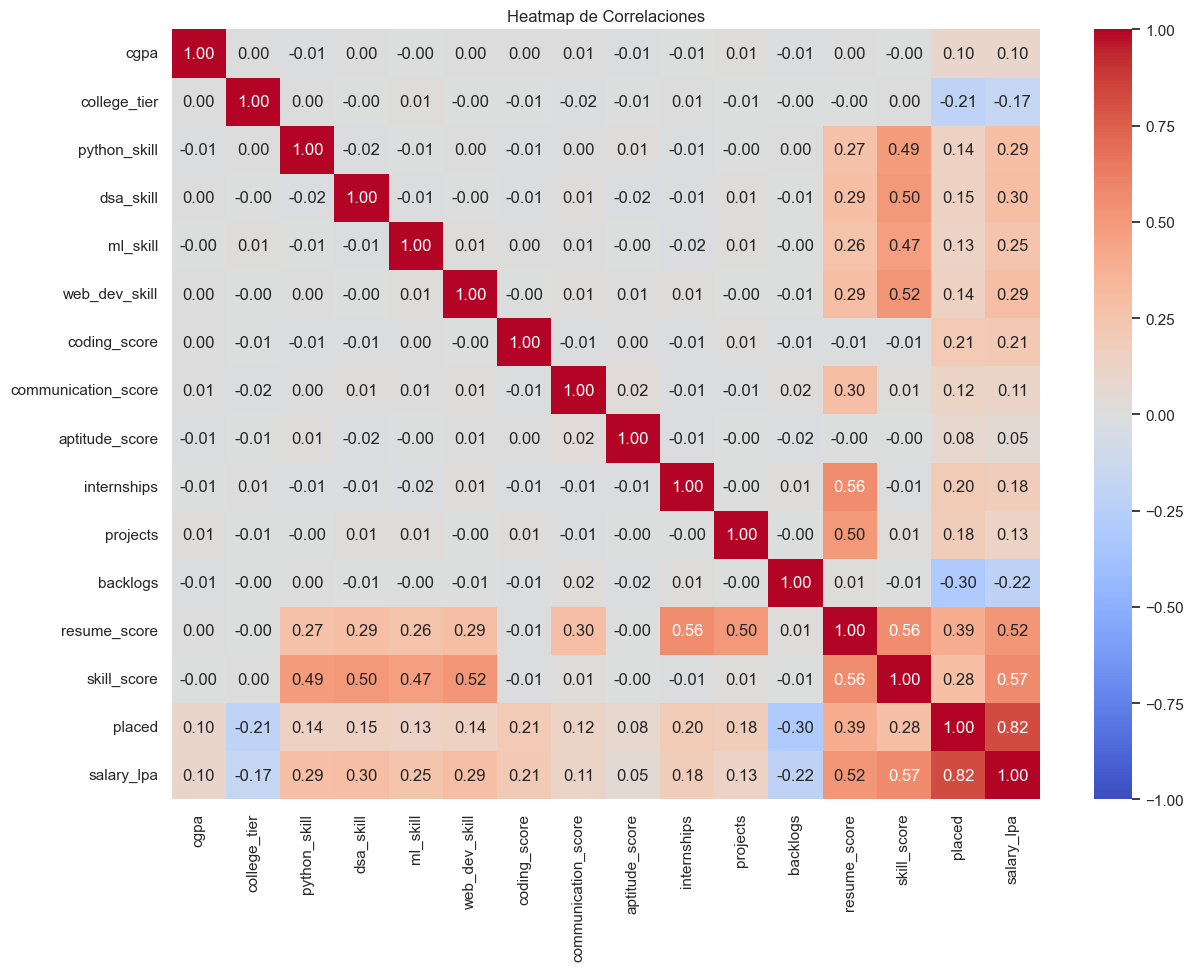


=== DETECCIÓN DE REDUNDANCIA E IRRELEVANCIA ===
Variables predictoras redundantes (|corr| > 0.85): []
No se detectaron variables predictoras altamente redundantes.

Variables potencialmente irrelevantes para 'placed' (|corr| < 0.05): []
Se recomienda analizar su impacto antes de eliminarlas completamente.


In [4]:
df_num = df.select_dtypes(include=np.number)
corr_matrix = df_num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap de Correlaciones')
plt.show()

print("\n=== DETECCIÓN DE REDUNDANCIA E IRRELEVANCIA ===")
# Redundantes > 0.85
redundantes = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            redundantes.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
print("Variables predictoras redundantes (|corr| > 0.85):", redundantes)
if redundantes:
    print("Sugerencia: Eliminar una variable de cada par redundante.")
else:
    print("No se detectaron variables predictoras altamente redundantes.")

# Irrelevantes < 0.05 con respecto a 'placed'
corr_objetivo = corr_matrix['placed'].abs()
irrelevantes = corr_objetivo[corr_objetivo < 0.05].index.tolist()
print("\nVariables potencialmente irrelevantes para 'placed' (|corr| < 0.05):", irrelevantes)
print("Se recomienda analizar su impacto antes de eliminarlas completamente.")

### Detección de Outliers (Boxplots)

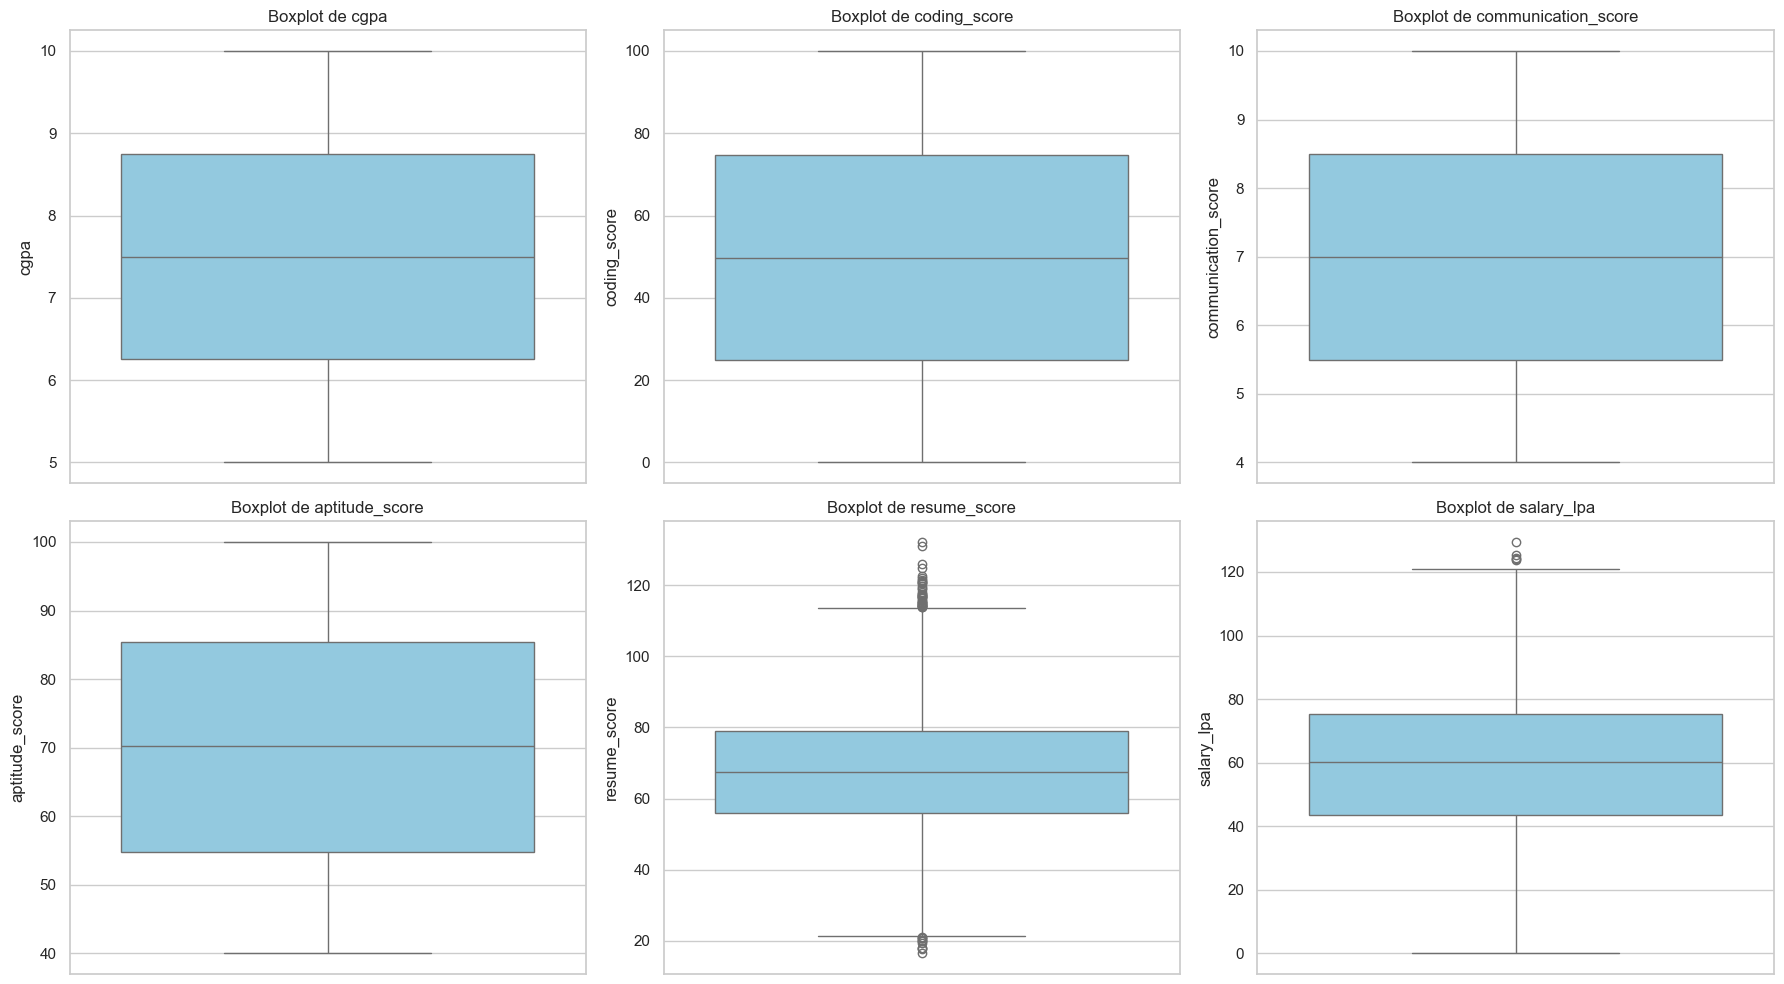

In [5]:
vars_to_plot = ['cgpa', 'coding_score', 'communication_score', 'aptitude_score', 'resume_score', 'salary_lpa']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.boxplot(y=df[var], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

## 4. Visualización de la Variable Objetivo y otras distribuciones

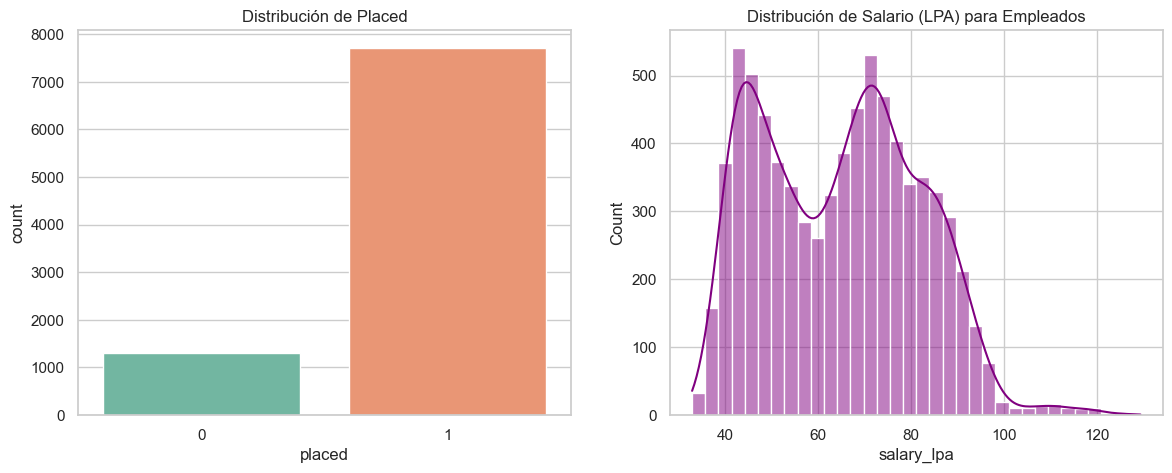

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='placed', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Placed')

sns.histplot(data=df[df['salary_lpa'] > 0], x='salary_lpa', kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribución de Salario (LPA) para Empleados')
plt.show()

## 5. Pandas Profiling Automatizado

Generando el reporte de Pandas Profiling. (Descomentar para ejecutar y guardar como HTML)

In [7]:
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile.to_file("pandas_profiling_report.html")
print("Reporte guardado como 'pandas_profiling_report.html'")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 53.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte guardado como 'pandas_profiling_report.html'


## 6. Preprocesamiento de Datos

En esta sección preparamos los datos para los modelos.

In [8]:
# 1. Eliminar student_id
df_prep = df.drop(columns=['student_id'])

# 2. Imputar nulos categóricos con 'Not_Applicable'
df_prep['company_type'] = df_prep['company_type'].fillna('Not_Applicable')
df_prep['job_role'] = df_prep['job_role'].fillna('Not_Applicable')

df_prep['company_type'] = df_prep['company_type'].replace('None', 'Not_Applicable')
df_prep['job_role'] = df_prep['job_role'].replace('None', 'Not_Applicable')

# 3. Separar features (X) y target de clasificación (y_class) y regresión (y_reg)
X = df_prep.drop(columns=['placed', 'salary_lpa'])
y_class = df_prep['placed']
y_reg = df_prep['salary_lpa']

# One Hot Encoding para EDA y partición (usaremos ColumnTransformer más adelante en el pipeline, pero aquí codificaremos para SMOTE)
X_encoded = pd.get_dummies(X, drop_first=True)
print("Forma de X_encoded después del One Hot Encoding:", X_encoded.shape)

Forma de X_encoded después del One Hot Encoding: (9000, 27)


## 7. Partición Train/Test y SMOTE

Usamos estratificación por la variable 'placed'.

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_class, test_size=0.30, stratify=y_class, random_state=42)

print("Distribución original en y_train:\n", y_train.value_counts(normalize=True))

# Aplicar SMOTE solo a entrenamiento asegurando que la clase minoritaria aumente sin superar el 25% de la mayoritaria.
# Nota: SMOTE por defecto balancea a 50/50. Podemos usar sampling_strategy para controlar la proporción.
# Para que minoritaria (0) represente el 25% de la mayoritaria (1), si la proporción original ya es > 25%, no se necesita mucha aumentación.
minority_proportion = y_train.value_counts(normalize=True).min()
print(f"\nProporción original de la clase minoritaria: {minority_proportion*100:.2f}%")

if minority_proportion < 0.25:
    print("Aplicando SMOTE para llevar la minoritaria a máximo 25%...")
    smote = SMOTE(sampling_strategy=0.33, random_state=42) # 0.33 de la mayoritaria equivale a un 25% del total aprox.
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print("\nDistribución tras SMOTE en y_train:\n", y_train_sm.value_counts(normalize=True))
else:
    print("\nLa clase minoritaria ya supera o es cercana al 25%, no se requiere SMOTE estricto o aplicamos SMOTE muy ligero.")
    # Si queremos aplicar SMOTE de todos modos para balancear levemente:
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print("\nDistribución tras SMOTE automático en y_train:\n", y_train_sm.value_counts(normalize=True))

X_train_sm.to_csv('X_train_prep.csv', index=False)
X_test.to_csv('X_test_prep.csv', index=False)
y_train_sm.to_csv('y_train_prep.csv', index=False)
y_test.to_csv('y_test_prep.csv', index=False)

print("\nDatos preprocesados y guardados.")

Distribución original en y_train:
 placed
1    0.855714
0    0.144286
Name: proportion, dtype: float64

Proporción original de la clase minoritaria: 14.43%
Aplicando SMOTE para llevar la minoritaria a máximo 25%...

Distribución tras SMOTE en y_train:
 placed
1    0.751883
0    0.248117
Name: proportion, dtype: float64

Datos preprocesados y guardados.
